In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Food chemistry: do topological descriptors add information?

**Beginner route:** read the [case lesson](../lessons/wine.md) and [dataset card](../cards/wine.md). Predict each result before executing.

Source: [Aeberhard and Forina (1992), Wine, UCI Machine Learning Repository.](https://archive.ics.uci.edu/dataset/109/wine). Snapshot obtained by offline export from sklearn 1.8.0. Numerical results below are our computations, not source claims.

This fixed test partition is a teaching demonstration, not an untouched future benchmark.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, mean_absolute_error, mean_squared_error, roc_auc_score, confusion_matrix
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/shape_lab").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.industries import *
from shape_lab.persistence import rips_filtration, persistent_homology, diagram
CASE = "wine"
OUT = ROOT / "reports/v6/industries" / CASE
OUT.mkdir(parents=True, exist_ok=True)
SEED = 20260920

def write_json(name, value):
    def convert(x):
        if isinstance(x, np.ndarray): return x.tolist()
        if isinstance(x, np.generic): return x.item()
        raise TypeError(type(x).__name__)
    (OUT / name).write_text(json.dumps(value, indent=2, default=convert, allow_nan=False))

def plot_done(name):
    plt.tight_layout()
    plt.savefig(OUT / (name + ".png"), dpi=125)
    plt.show()

def regression_metrics(y, pred):
    return {"mae":float(mean_absolute_error(y,pred)),"rmse":float(mean_squared_error(y,pred)**.5)}

def class_metrics(y, pred):
    return {"accuracy":float(accuracy_score(y,pred)),"balanced_accuracy":float(balanced_accuracy_score(y,pred))}

def stratified_split(y):
    index=np.arange(len(y))
    train, other=train_test_split(index,test_size=.4,random_state=SEED,stratify=y)
    val,test=train_test_split(other,test_size=.5,random_state=SEED,stratify=y[other])
    return {"train":np.sort(train),"validation":np.sort(val),"test":np.sort(test)}

def save_split(split, ids):
    frames=[pd.DataFrame({"example_index":v,"source_id":np.asarray(ids)[v],"partition":k}) for k,v in split.items()]
    pd.concat(frames,ignore_index=True).to_csv(OUT / "split.csv",index=False)

def topology_report(points, name):
    bars=persistent_homology(rips_filtration(points,max_homology=1),max_dim=1)
    finite=[{"dimension":b.dim,"birth":b.birth,"death":b.death} for b in bars if np.isfinite(b.death)]
    write_json(name+".json",{"points":len(points),"coefficient_field":2,"edge_convention":"distance <= epsilon","finite_bars":finite,"essential_h0":1,"role":"exploratory descriptor, not significance"})
    plt.figure(figsize=(7,4))
    for dim in (0,1):
        a=diagram(bars,dim,finite_only=True)
        if len(a): plt.scatter(a[:,0],a[:,1],label="H"+str(dim),s=22)
    plt.xlabel("Birth (declared metric units)");plt.ylabel("Death (same units)");plt.title(name.replace('_',' '));plt.legend()
    plot_done(name)
    return finite

df, meta = load_dataset(CASE)
print(meta["title"])
print("Shape:",df.shape,"; snapshot SHA-256:",meta["data_sha256"])
print("Observation unit:",meta["observation_unit"])
display(df.head())
write_json("protocol.json",{"dataset":CASE,"seed":SEED,"data_sha256":meta["data_sha256"],"code_sha256":hashlib.sha256((ROOT/"src/shape_lab/industries.py").read_bytes()).hexdigest(),"data_kind":"observed","evaluation":"fixed teaching experiment; displayed test outcomes are now exposed","external_validation":False})


Chemistry, scale and out-of-sample topological descriptors
Shape: (178, 15) ; snapshot SHA-256: 2f6d6d39c2ba1898b9d254feb78ae575383fac1f9ed735c9aaa9308293568aac
Observation unit: One wine sample; cultivar is a category, not a quality score.


,row_id,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,label
0,0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


## 1. Distinguish measurement, cultivar and quality

The target identifies three cultivars, not consumer quality or safety. A change from grams to milligrams can alter raw Euclidean distances. Standardization is therefore an explicit modeling choice, fitted on training data only.

Our comparison gives every model the **same supervised fitting rows**. A separate subset of training rows is reserved as a fixed reference cloud.

In [3]:
features=[c for c in df if c not in ("row_id","label")];x=df[features].to_numpy(float);y=df.label.to_numpy(int)
split=stratified_split(y);save_split(split,df.row_id)
scaler=TrainScaler.fit(x[split["train"]]);z=scaler.transform(x)
order=np.random.default_rng(SEED).permutation(split["train"])
anchors=order[:30];fit_rows=np.sort(order[30:])
assert not(set(anchors)&set(fit_rows))
assert not(set(anchors)&set(split["test"]))
write_json("preprocessing.json",{"feature_names":features,"mean":scaler.mean,"scale":scaler.scale,"anchor_rows":anchors,"supervised_rows":fit_rows,"neighbors":8})
print("Reference rows:",len(anchors),"supervised rows:",len(fit_rows))

Reference rows: 30 supervised rows: 76


## 2. Define a descriptor that can be applied to an unseen row

For one query, choose its eight nearest training reference points. Form the nine-point Rips complex through dimension two. Summarize finite H0 merge lengths and H1 lifetimes. The reference set is frozen; test observations never become reference points.

The six numbers are engineered local summaries. They are not a magical recovery of the topology of one vector. Small complete complexes keep the computation inspectable.

In [4]:
descriptor_names=["h0_mean","h0_std","h0_max","h1_count","h1_max_lifetime","h1_total_lifetime"]
needed=np.r_[fit_rows,split["validation"],split["test"]]
top=np.full((len(df),6),np.nan)
top[needed]=local_topology(z[needed],z[anchors],k=8)
assert np.isfinite(top[needed]).all()
top_scaler=TrainScaler.fit(top[fit_rows]);ts=np.full_like(top,np.nan);ts[needed]=top_scaler.transform(top[needed])
pd.DataFrame(top[needed],columns=descriptor_names,index=needed).rename_axis("row_id").to_csv(OUT/"topological_features.csv")
write_json("topology_preprocessing.json",{"names":descriptor_names,"mean":top_scaler.mean,"scale":top_scaler.scale,"fit_rows":fit_rows})
print(pd.DataFrame(top[fit_rows],columns=descriptor_names).describe().round(3))

       h0_mean  h0_std  h0_max  h1_count  h1_max_lifetime  h1_total_lifetime
count   76.000  76.000  76.000    76.000           76.000             76.000
mean     2.404   0.405   3.093     0.776            0.102              0.114
std      0.251   0.172   0.494     0.810            0.144              0.164
min      1.932   0.131   2.267     0.000            0.000              0.000
25%      2.196   0.268   2.731     0.000            0.000              0.000
50%      2.421   0.389   2.994     1.000            0.047              0.047
75%      2.563   0.517   3.279     1.000            0.169              0.198
max      3.156   0.941   5.025     3.000            0.622              0.722


## 3. Compare raw, topological, and combined representations

C=1, eight neighbors and thirty anchors are fixed teaching choices—not the outcome of a hidden test-set search. We show validation and test scores separately. A win here would be a result for this one protocol, not evidence that topology is generally superior.

,raw,topology,combined,majority
accuracy,0.888889,0.638889,0.944444,0.388889
balanced_accuracy,0.895238,0.669048,0.942857,0.333333


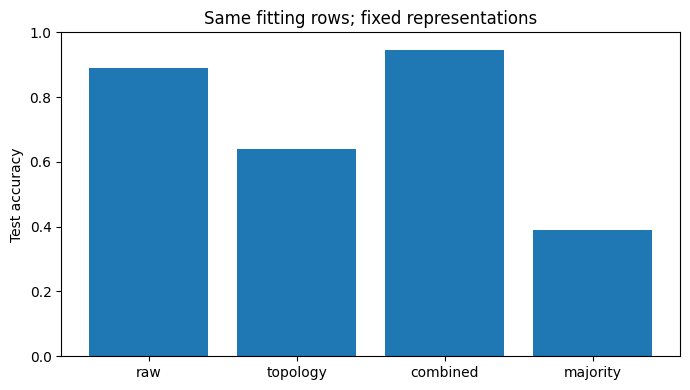

In [5]:
representations={"raw":z,"topology":ts,"combined":np.column_stack((z,ts))}
results={};predictions={}
for name,a in representations.items():
    model=LogisticRegression(C=1,max_iter=3000,random_state=SEED).fit(a[fit_rows],y[fit_rows])
    results[name]={}
    for key in ("validation","test"):
        ix=split[key];pred=model.predict(a[ix]);results[name][key]=class_metrics(y[ix],pred)
        if key=="test": predictions[name]=pred
majority=int(np.bincount(y[fit_rows]).argmax());results["majority"]={k:class_metrics(y[ix],np.full(len(ix),majority)) for k,ix in split.items() if k!="train"}
write_json("results.json",results)
pd.DataFrame({"row_id":split["test"],"cultivar":y[split["test"]],**predictions}).to_csv(OUT/"test_predictions.csv",index=False)
display(pd.DataFrame({name:r["test"] for name,r in results.items()}))
plt.figure(figsize=(7,4));plt.bar(list(results),[r["test"]["accuracy"] for r in results.values()]);plt.ylim(0,1)
plt.ylabel("Test accuracy");plt.title("Same fitting rows; fixed representations")
plot_done("comparison")

## 4. Check a property, not just a score

Multiplying all standardized coordinates by two should multiply Rips birth/death distances by two. Counts need not be reinterpreted as physical units. The assertion below tests the descriptor contract independently of cultivar prediction. Then explain why arbitrary feature-wise scaling is a different operation.

In [6]:
q=z[split["validation"][:2]];a=z[anchors]
one=local_topology(q,a,k=8);two=local_topology(2*q,2*a,k=8)
np.testing.assert_allclose(two[:,[0,1,2,4,5]],2*one[:,[0,1,2,4,5]],atol=1e-10)
np.testing.assert_allclose(two[:,3],one[:,3]);print("Uniform-scale contract passed")

Uniform-scale contract passed


## Save your evidence

Create `my_work/industries/wine.md` with your prediction, actual result, explanation, one failed assumption and one claim the evidence does not justify. Use the separate learner notebook only after you understand the worked code. No notebook execution automatically marks your learning complete.